In [2]:

import sys
from scipy.stats import sem
sys.path.append('/Users/michaelfinch/CA1-interneuron-GLM')

from utils_TCA_clustering_scratchpad import *
from GLM_regression_plotting import *

import os, time, sys, platform

# activity_dict, double_predicted_activity_dict_NDNF_new, filtered_factors_dict, double_new_NDNF_activity_dict, double_new_NDNF_velocity_dict, double_residual_activity_dict_NDNF_new = load_data_double(name="NDNFanalC", double_track=False)
# activity_dict, filtered_factors_dict, double_new_NDNF_activity_dict_100, double_new_NDNF_velocity_dict_100, double_residual_activity_dict_NDNF_new_100 = load_data_double(name="NDNFanalC", double_track=True)

# GLM_params, activity_dict, double_predicted_activity_dict_NDNF_new, factors_dict, filtered_factors_dict, residual_activity_dict_NDNF_new = load_data_regular(name="NDNFanalC", new_NDNF=True)
# GLM_params_old_NDNF, activity_dict_old_NDNF, double_predicted_activity_dict_NDNF_old, factors_dict_old_NDNF, filtered_factors_dict_old_NDNF, residual_activity_dict_NDNF_old = load_data_regular(name="NDNFindivsomata_GLM", new_NDNF=False)
GLM_params_SST, activity_dict_SST, double_predicted_activity_dict_SST, factors_dict_SST, filtered_factors_dict_SST, residual_activity_dict_SST = load_data_regular(file_path='/Users/michaelfinch/CA1-interneuron-GLM', name="SSTindivsomata_GLM", new_NDNF=False)
GLM_params_EC, activity_dict_EC, double_predicted_activity_dict_EC, factors_dict_EC, filtered_factors_dict_EC, residual_activity_dict_EC = load_data_regular(file_path='/Users/michaelfinch/CA1-interneuron-GLM', name="EC_GLM", new_NDNF=False)


GLM_params_NDNF_newest, activity_dict_NDNF_newest, double_predicted_activity_dict_NDNF_newest, factors_dict_NDNF_newest, filtered_factors_dict_NDNF_newest, residual_activity_dict_NDNF_newest = load_data_regular(file_path='/Users/michaelfinch/CA1-interneuron-GLM', name="NDNF_E1A1B", new_NDNF=True)

fixed_residual_activity_dict_NDNF_newest = {}
for idx, animal in enumerate(residual_activity_dict_NDNF_newest):
    if 17 < idx < 31:
        fixed_residual_activity_dict_NDNF_newest[f"animal_{idx+1}"] = residual_activity_dict_NDNF_newest[animal]

fixed_activity_dict_NDNF_newest = {}
for idx, animal in enumerate(activity_dict_NDNF_newest):
    if 17 < idx < 31:
        fixed_activity_dict_NDNF_newest[f"animal_{idx+1}"] = activity_dict_NDNF_newest[animal]

fixed_filtered_factors_dict_NDNF_newest = {}
for idx, animal in enumerate(filtered_factors_dict_NDNF_newest):
    if 17 < idx < 31:
        fixed_filtered_factors_dict_NDNF_newest[f"animal_{idx+1}"] = filtered_factors_dict_NDNF_newest[animal]



/Users/michaelfinch/CA1-interneuron-GLM/utils.py:7: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [3]:
def _sanitize_velocity_cm_s(v_in_m_per_s, min_vel_cm_s=1e-3 * 100):
    """
    Convert m/s -> cm/s and make strictly positive.
    Accepts 1D (n_pos,) or 2D (n_pos, n_trials). Returns same shape.
    Fills NaNs/<=0 by interpolation along the position axis, per trial.
    """

    v = np.asarray(v_in_m_per_s, dtype=np.float32) * np.float32(100.0)  # m/s -> cm/s

    def _sanitize_1d(x):
        # operate on the passed slice, not on the outer 'v'
        bad = ~np.isfinite(x) | (x <= 0)
        if bad.any():
            good_idx = np.flatnonzero(~bad)
            bad_idx  = np.flatnonzero(bad)
            if good_idx.size >= 2:
                x[bad] = np.interp(bad_idx, good_idx, x[good_idx])
            elif good_idx.size == 1:
                x[bad] = x[good_idx[0]]
            else:
                x[:] = np.float32(10.0)  # fallback if everything is bad
        return np.maximum(x, np.float32(min_vel_cm_s))

    if v.ndim == 1:
        return _sanitize_1d(v)
    if v.ndim == 2:
        out = v.copy()
        for t in range(out.shape[1]):
            out[:, t] = _sanitize_1d(out[:, t])
        return out
    raise ValueError(f"sanitize_velocity_cm_s: expected 1D or 2D, got shape {v.shape}")

In [4]:
def turn_rates_into_spikes_new(dend_list_EC, animal_velocity_list, dt_constant=None, animal_av_vel=True):

    dt_ms = dt_constant*1000.

    EC_input_matrix = np.stack(dend_list_EC, axis=0)

    print(f"EC_input_matrix.shape {EC_input_matrix.shape}")

    n_EC = EC_input_matrix.shape[0]
    n_pos = EC_input_matrix.shape[1]
    n_trials = EC_input_matrix.shape[2]

    dx = 180.0 / n_pos  


    warped_list = []

    if animal_av_vel:
        an_velocity = np.array(animal_velocity_list)
        an_velocity = np.nanmean(an_velocity, axis=0)
        print(f"an_velocity.shape {an_velocity.shape}")

    for t in range(EC_input_matrix.shape[2]):

        warped_rows = [] 

        for cell in range(n_EC):

            v_cm_s = _sanitize_velocity_cm_s(an_velocity[:, t]) 
            dt_s   = dx / v_cm_s                             
            edges_s = np.concatenate(([0.0], np.cumsum(dt_s)))
            total_time = float(edges_s[-1])

            t_axis = np.arange(0.0, total_time, dt_constant, dtype=np.float64)
        

            firing_example = EC_input_matrix[0, :, t].astype(np.float64, copy=False)
            valid = np.isfinite(firing_example)
            time_points = np.cumsum(dt_s)
            
            animal_velocity_list
            firing = EC_input_matrix[cell, :, t].astype(np.float64, copy=False)
            valid = np.isfinite(firing)
            if valid.sum() >= 2:
                time_points = np.cumsum(dt_s)  # length n_pos

                warped = np.interp(t_axis, time_points[valid], firing[valid]).astype(np.float32, copy=False)
                
            else:
                warped = np.full(1, np.nan, dtype=np.float32)
                
            warped_rows.append(warped)

        warped_rows_array = np.array(warped_rows)
        print(f"warped_rows_array.shape {warped_rows_array.shape}")

        warped_list.append(warped_rows_array) 
        
    return warped_list, an_velocity



In [7]:
def get_dend_VM_cell_type_new(residual_activity_dict_EC, factors_dict_EC, GLM_params_EC, include_beta=True, const_vel=True, flat_input=False, animal_by_animal=False, animal_used=None):

    data_list_normalized = []

    for animal in residual_activity_dict_EC:
        for cell in residual_activity_dict_EC[animal]:
            data_normalized = residual_activity_dict_EC[animal][cell][:,:58]
            data_normalized = ((data_normalized - np.min(data_normalized)) / (np.max(data_normalized) - np.min(data_normalized))) *50
            data_list_normalized.append(data_normalized)


    data_array_normalized = np.array(data_list_normalized)

    mu= np.mean(data_list_normalized)
    sigma = np.std(data_list_normalized)

    print(f"mu={mu} sigma={sigma}")

    dendrite = np.zeros((50, 58))
    
    dendrite_list = []


    dendrite_ta_list = []


    # if use_averaged_velocity=="cell_type_av":
    #     animal_velocity = np.tile(mean_new_average_vel_array[:, np.newaxis], (1, 58))

    animal_velocity_list = []


    if animal_by_animal:
        animal = animal_used
        for cell in residual_activity_dict_EC[animal]:
            data = residual_activity_dict_EC[animal][cell]
            data = data[:,:58]

            if flat_input:
                data = np.zeros((data.shape))

            weights = GLM_params_EC[animal][cell]['weights']["Velocity"]
            # intercept = GLM_params[animal][cell]['intercept']

            if const_vel:
                animal_velocity = np.full((50, 58), 0.43)
                animal_velocity_list.append(animal_velocity)

                if include_beta:
                
                    data = data + mu + (weights * animal_velocity * sigma) #+ intercept

                else:
                    data = data + mu

                dendrite_ta_list.append(np.mean(data, axis=1))


            else:
                # if use_averaged_velocity=="cell_type_av":
                #     animal_velocity = np.tile(mean_new_average_vel_array[:, np.newaxis], (1, 58))
                # elif use_averaged_velocity=="actual_velocity":
                animal_velocity = factors_dict_EC[animal]["Velocity"][:,:58]
                animal_velocity_list.append(animal_velocity)
                
                if include_beta:
                
                    data = data + mu + (weights * animal_velocity * sigma) #+ intercept

                else:
                    data = data + mu

                dendrite_ta_list.append(np.mean(data, axis=1))



            dendrite += data
            dendrite_list.append(data)


    else:
        for animal in residual_activity_dict_EC:
            for cell in residual_activity_dict_EC[animal]:
                data = residual_activity_dict_EC[animal][cell]
                data = data[:,:58]

                if flat_input:
                    data = np.zeros((data.shape))

                weights = GLM_params_EC[animal][cell]['weights']["Velocity"]
                # intercept = GLM_params[animal][cell]['intercept']

                if const_vel:
                    animal_velocity = np.full((50, 58), 0.43)
                    animal_velocity_list.append(animal_velocity)

                    if include_beta:
                    
                        data = data + mu + (weights * animal_velocity * sigma) #+ intercept

                    else:
                        data = data + mu

                    dendrite_ta_list.append(np.mean(data, axis=1))


                else:
                    # if use_averaged_velocity=="cell_type_av":
                    #     animal_velocity = np.tile(mean_new_average_vel_array[:, np.newaxis], (1, 58))
                    # elif use_averaged_velocity=="actual_velocity":
                    animal_velocity = factors_dict_EC[animal]["Velocity"][:,:58]
                    animal_velocity_list.append(animal_velocity)
                    
                    if include_beta:
                    
                        data = data + mu + (weights * animal_velocity * sigma) #+ intercept

                    else:
                        data = data + mu

                    dendrite_ta_list.append(np.mean(data, axis=1))



                dendrite += data
                dendrite_list.append(data)

                                            
    # if add_vel_contribution:
    #     if use_averaged_velocity=="actual_velocity":
    #         # if add_inh == 'both' or add_inh == 'sst':
    #         animal_velocity_array = np.array(animal_velocity_list)
    #         animal_velocity = np.mean(animal_velocity_array, axis=0)
    #         # else:
    #         #     animal_velocity_array = np.array(animal_velocity_list)
    #         #     animal_velocity = np.mean(animal_velocity_array, axis=2)

    return animal_velocity_list, dendrite_list, dendrite_ta_list



# animal_velocity, dendrite_list, dendrite_ta_list = get_dend_VM_cell_type_new(residual_activity_dict_EC, factors_dict_EC, GLM_params_EC, include_beta=True, const_vel=False, flat_input=True)


# dendrite_ta_array = np.array(dendrite_ta_list)

# mean_dendrite_ta_array = np.mean(dendrite_ta_array, axis=0)
# sem_dendrite_ta_array = sem(dendrite_ta_array, axis=0)

# dend_vm_list, weights_EC, last_EPSP, min_trial_length = turn_rates_into_spikes(synthetic_data_plus_vel_list, an_velocity, dist, kernel, dt_constant=dt_constant, n_dendrites=100, store_intermediates=False, rng=rng)

# plt.plot(mean_dendrite_ta_array)
# plt.title(f"Constant Velocity={const_vel} Flat Data={flat_input} Include Beta={include_beta}")
# plt.fill_between(range(len(mean_dendrite_ta_array)), mean_dendrite_ta_array+sem_dendrite_ta_array, mean_dendrite_ta_array-sem_dendrite_ta_array, alpha=0.2)


In [8]:
def get_warped_array(warped_list):
    num_trials = len(warped_list)
    n_cells_ = warped_list[0].shape[0]
    max_T = max(arr.shape[1] for arr in warped_list)  # <-- time axis length

    warped_array_padded = np.full((num_trials, n_cells_, max_T), np.nan, dtype=np.float32)

    for i, arr in enumerate(warped_list):
        if arr.shape[0] != n_cells_:
            raise ValueError(f"Trial {i}: n_cells_ mismatch: {arr.shape[0]} != {n_cells_}")
        Ti = arr.shape[1]               # current trial's time length
        warped_array_padded[i, :, :Ti] = arr # pad along time axis

    return warped_array_padded

mu=9.57566692460854 sigma=6.531949990210035
len(dendrite_list) 792 dendrite_list[0].shape (50, 58)
EC_input_matrix.shape (792, 50, 58)
an_velocity.shape (50, 58)
warped_rows_array.shape (792, 3927)
warped_rows_array.shape (792, 3576)
warped_rows_array.shape (792, 4126)
warped_rows_array.shape (792, 4465)
warped_rows_array.shape (792, 4741)
warped_rows_array.shape (792, 4802)
warped_rows_array.shape (792, 4991)
warped_rows_array.shape (792, 5350)
warped_rows_array.shape (792, 5182)
warped_rows_array.shape (792, 5080)
warped_rows_array.shape (792, 5507)
warped_rows_array.shape (792, 5430)
warped_rows_array.shape (792, 5364)
warped_rows_array.shape (792, 5393)
warped_rows_array.shape (792, 4862)
warped_rows_array.shape (792, 4599)
warped_rows_array.shape (792, 4942)
warped_rows_array.shape (792, 5188)
warped_rows_array.shape (792, 5281)
warped_rows_array.shape (792, 4868)
warped_rows_array.shape (792, 5014)
warped_rows_array.shape (792, 5318)
warped_rows_array.shape (792, 5569)
warped_row

/var/folders/hl/zfn0lkv15xx80f47pqqz8p9c0000gn/T/ipykernel_51387/1994485374.py:37: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  sem_over_trials = sem(mean_cells_warped_array_padded, axis=0, nan_policy='omit')[:7000]


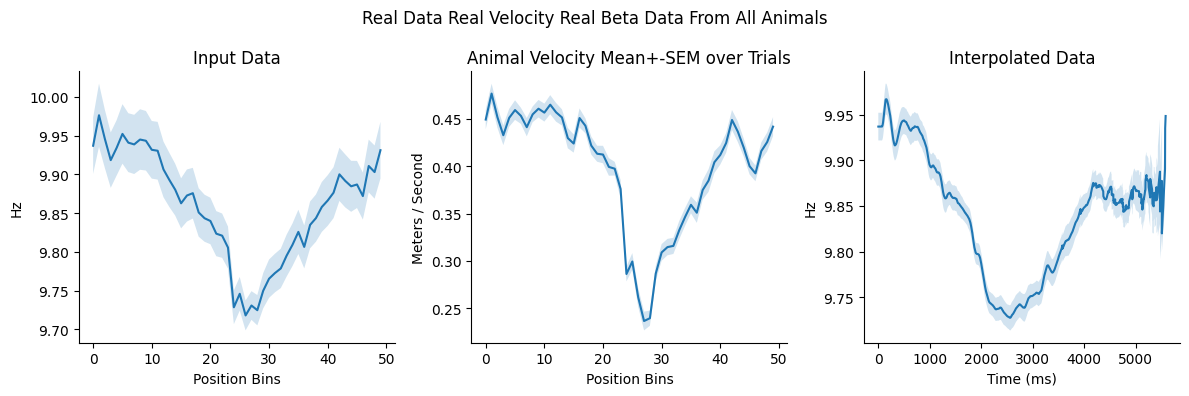

In [24]:

def plot_interpolated_findings(residual_activity_dict_EC, factors_dict_EC, GLM_params_EC, include_beta=None, const_vel=None, flat_input=None, dt_constant=0.001, animal_by_animal=False, animal_used=None):

    if const_vel:
        vel_str = "Flat Velocity"
    else:
        vel_str = "Real Velocity"
    
    if flat_input:
        input_str = "Synthetic Data"
    else:
        input_str = "Real Data"
    
    if include_beta:
        beta_str = "Real Beta"
    else:
        beta_str = "No Beta"

    animal_velocity_list, dendrite_list, dendrite_ta_list = get_dend_VM_cell_type_new(residual_activity_dict_EC, factors_dict_EC, GLM_params_EC, include_beta=include_beta, const_vel=const_vel, flat_input=flat_input, animal_by_animal=animal_by_animal, animal_used=animal_used)

    print(f"len(dendrite_list) {len(dendrite_list)} dendrite_list[0].shape {dendrite_list[0].shape}")
    warped_list, an_velocity = turn_rates_into_spikes_new(dendrite_list, animal_velocity_list, dt_constant=dt_constant)

    animal_velocity_array = np.array(animal_velocity_list)

    dendrite_ta_array = np.array(dendrite_ta_list)

    mean_dendrite_ta_array = np.mean(dendrite_ta_array, axis=0)
    sem_dendrite_ta_array = sem(dendrite_ta_array, axis=0)

    print(f"len(warped_list) {len(warped_list)}")

    warped_array_padded = get_warped_array(warped_list)


    mean_cells_warped_array_padded = np.mean(warped_array_padded, axis=1)
    mean_over_trials = np.nanmean(mean_cells_warped_array_padded, axis=0)[:7000]
    sem_over_trials = sem(mean_cells_warped_array_padded, axis=0, nan_policy='omit')[:7000]

    

    fig, axs = plt.subplots(1,3, figsize=(12,4))

    if animal_by_animal:
        plt.suptitle(f"{input_str} {vel_str} {beta_str} Data From {animal_used} Only")
    else:
        plt.suptitle(f"{input_str} {vel_str} {beta_str} Data From All Animals")

    axs[0].plot(mean_dendrite_ta_array)
    axs[0].set_title("Input Data")
    axs[0].fill_between(range(len(mean_dendrite_ta_array)), mean_dendrite_ta_array+sem_dendrite_ta_array, mean_dendrite_ta_array-sem_dendrite_ta_array, alpha=0.2)
    axs[0].set_ylabel("Hz")
    axs[0].set_xlabel("Position Bins")
    # axs[0].set_ylim(9.5,10.1)

    axs[2].plot(mean_over_trials)
    axs[2].set_title("Interpolated Data")
    axs[2].fill_between(range(len(mean_over_trials)), mean_over_trials+sem_over_trials, mean_over_trials-sem_over_trials, alpha=0.2)
    axs[2].set_ylabel("Hz")
    axs[2].set_xlabel("Time (ms)")
    # axs[2].set_ylim(9.5,10.1)


    an_velocity = np.mean(animal_velocity_array, axis=0)
    mean_an_vel = np.mean(an_velocity, axis=1)
    sem_an_vel = sem(an_velocity, axis=1)
    axs[1].set_title("Animal Velocity Mean+-SEM over Trials")
    axs[1].set_ylabel("Meters / Second")
    axs[1].set_xlabel("Position Bins")
    axs[1].plot(mean_an_vel)
    axs[1].fill_between(range(len(mean_an_vel)), mean_an_vel+sem_an_vel, mean_an_vel-sem_an_vel, alpha=0.2)

    plt.tight_layout()
    plt.show()

flat_input = False
const_vel = False
include_beta = True

animal_by_animal = False
animal_used = 'animal_2'

plot_interpolated_findings(residual_activity_dict_EC, factors_dict_EC, GLM_params_EC, include_beta=include_beta, const_vel=const_vel, flat_input=flat_input, dt_constant=0.001, animal_by_animal=animal_by_animal, animal_used=animal_used)
